In [ ]:
import spconv.pytorch as sp
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from torchinfo import summary
import ad_tools.tools as tools
import numpy as np
import awkward as ak

In [ ]:
images = ak.from_parquet("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", row_groups = range(10), columns=  "cell_towers")

In [ ]:
images = ak.to_torch(images.cell_towers).to(torch.float32).view(-1,50,64,6).permute(dims = (0,3,1,2))

In [ ]:
images.shape

torch.Size([1000, 6, 50, 64])

In [25]:
blank = torch.zeros_like(images)

In [26]:
blank.shape

torch.Size([1000, 6, 50, 64])

In [30]:
torch.mean(F.mse_loss(images, blank, reduction = "none"))

tensor(0.0332)

In [2]:
class BetaVAEMark4Encoder(nn.Module):
    """
    Beta VAE Mark 4 Encoder
    """

    def __init__(self, latent_dim = 7):
        super().__init__()
        self.submanspconv1 = sp.SubMConv2d(in_channels = 6, out_channels = 8, kernel_size = 3)
        self.sppool1 = sp.SparseConv2d(in_channels = 8, out_channels = 8,kernel_size= 2, stride = 2)
        self.submanspconv2 = sp.SubMConv2d(in_channels = 8, out_channels = 16, kernel_size = 3)
        self.sppool2 = sp.SparseConv2d(in_channels = 16, out_channels = 16, kernel_size= (5,2), stride = (5,2))
        self.submanspconv3 = sp.SubMConv2d(in_channels = 16, out_channels = 32, kernel_size = 3)
        self.sppool3 = sp.SparseConv2d(in_channels = 32, out_channels = 32, kernel_size= (5,2), stride = (5,2))
        self.flatten = nn.Flatten(start_dim = 1)
        self.mu = nn.Linear(256, latent_dim)
        self.logvar = nn.Linear(256, latent_dim)


    def forward(self, input):
        # Convolutional Block 1
        input = torch.permute(input, dims = (0,2,3,1))
        input = sp.SparseConvTensor.from_dense(input)
        output1 = self.submanspconv1(input)
        output2 = output1.replace_feature(F.leaky_relu(output1.features))
        output3 = self.sppool1(output2)



        # Convolutional Block 2
        output4 = self.submanspconv2(output3)
        output5 = output4.replace_feature(F.leaky_relu(output4.features))
        output6 = self.sppool2(output5)



        # Convolutional Block 3
        output7 = self.submanspconv3(output6)
        output8 = output7.replace_feature(F.leaky_relu(output7.features))
        output9 = self.sppool3(output8)



        # Latent space mapping
        output10 = output9.dense()
        output11 = self.flatten(output10)
        mu = self.mu(output11)
        logvar = self.logvar(output11)
        
        return mu, logvar
    

class BetaVAEMark4Decoder(nn.Module):
    """
    Beta VAE Mark 4 Decoder
    """



    def __init__(self, latent_dim = 7):
        super().__init__()
        self.linear = nn.Linear(latent_dim, 256)
    
        self.unpool1 = sp.SparseConvTranspose2d(in_channels = 32, out_channels = 32, kernel_size = (5,2), stride = 2)
        self.transconv1 = sp.SparseConvTranspose2d(in_channels = 32 , out_channels = 16 ,kernel_size = 3, padding = (1,1))
        
        self.unpool2 = sp.SparseConvTranspose2d(in_channels = 16, out_channels = 16, kernel_size = (5,2), stride = (5,2))
        self.transconv2 = sp.SparseConvTranspose2d(in_channels = 16 , out_channels = 8 ,kernel_size = 3, padding = (1,1))
        
        self.unpool3 = sp.SparseConvTranspose2d(in_channels = 8, out_channels = 8,kernel_size = 2, stride = 2)
        self.transconv3 = sp.SparseConvTranspose2d(in_channels = 8 , out_channels = 6 ,kernel_size = 3, padding = (1,1))



    def forward(self, latent_vector):
        output1 = self.linear(latent_vector)
        output2 = F.leaky_relu(output1)
        output3 = torch.permute(torch.reshape(output2, shape = (-1,32,1,8)), dims = (0,2,3,1))
        output4 = sp.SparseConvTensor.from_dense(output3)


        
        # Deconvolution Block 1
        output5 = self.unpool1(output4)
        output6 = self.transconv1(output5)
        output7 = output6.replace_feature(F.leaky_relu(output6.features))



        # Deconvolution Block2
        output8 = self.unpool2(output7)
        output9 = self.transconv2(output8)
        output10 = output9.replace_feature(F.leaky_relu(output9.features))



        # Deconvolution Block8
        output11 = self.unpool3(output10)
        output12 = self.transconv3(output11)
        output13 = output12.replace_feature(F.relu(output12.features))
        output14 = output13.dense()
        return output14
    

class BetaVAEMark4(nn.Module):
    """
    Beta VAE Mark 4.
    """

    def __init__(self, latent_dim = 7):
        super().__init__()
        self.encoder = BetaVAEMark4Encoder(latent_dim= latent_dim)
        self.decoder = BetaVAEMark4Decoder(latent_dim=latent_dim)

    def reparameterise(self, mu, logvar):
        std = torch.zeros_like(logvar)
        #std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) 
        return mu + eps * std
    
    def forward(self, input):
        mu, logvar = self.encoder(input)
        z = self.reparameterise(mu, logvar)
        output = self.decoder(z)
        return output, mu, logvar,z

# Beta = 0, kl removed, norm clipping 0.01, lr = 1e-3

In [5]:
model = BetaVAEMark4().to(device)
model.load_state_dict(torch.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark4/Beta01/weights/BetaVAE4test_weights_epoch47.pth"))
#, map_location = torch.device('cpu')))

<All keys matched successfully>

In [6]:
tools.test(model = model,
           signal_acceptance_directory = "/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark4/Beta01/signal_acceptance_rates",
           phi_invariance_study_directory="/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark4/Beta01/phi_invariance_study",
           latent_code_directory="/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark4/Beta01/latent_vectors",
           testing_losses_directory="/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark4/Beta01/testing_losses")

KeyboardInterrupt: 

# 256 latent

In [2]:
import numpy as np
jz0_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark4/Beta0_lr3_l256/latent_vectors/jz0_latent_codes.npy")
ggf_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark4/Beta0_lr3_l256/latent_vectors/ggF_latent_codes.npy")

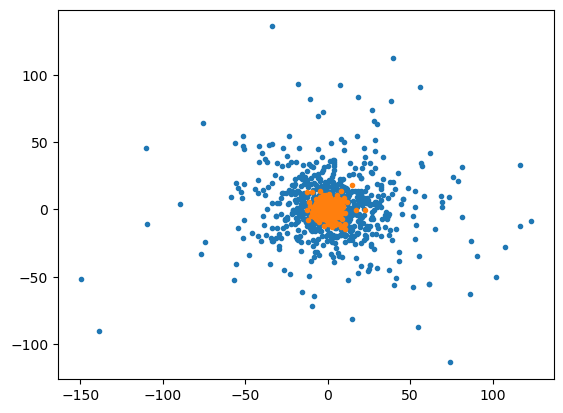

In [14]:
import matplotlib.pyplot as plt
plt.plot(ggf_latent_codes[:1000,0,0],ggf_latent_codes[:1000,0,1], ".")
plt.plot(jz0_codes[:1000,0,0],jz0_codes[:1000,0,1], ".")
